# EX - Mall Customers klasterdamine

See mall annab sulle peatükid ja kohad, kuhu oma analüüs ning järeldused lisada. Täida koodiplokid ja lisa lühikesed selgitused, miks valisid need sammud. Fail `mall_customers.csv` peab asuma sama kausta sees.



## 1. Andmete laadimine

Impordi vajalikud teegid, loe `mall_customers.csv` DataFrame'i ning näita mõõtmeid ja esimesi ridu, et kinnitada, et fail on korras.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import sys

if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/Colab Notebooks/mall_customers.csv'
else:
    path = 'mall_customers.csv'

df = pd.read_csv(path)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic statistics:")
df.describe()

Shape: (200, 5)
Columns: ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Missing values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Basic statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 2. Tunnuste valik ja skaleerimine

Vali veerud `Annual Income (k$)` ja `Spending Score (1-100)`, moodusta `X`, skaleeri andmed kasutades `StandardScaler`'it.



In [2]:
feature_columns = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"X shape: {X.shape}")
print(f"X_scaled mean: {X_scaled.mean(axis=0).round(6)}")
print(f"X_scaled std:  {X_scaled.std(axis=0).round(6)}")

X shape: (200, 2)
X_scaled mean: [-0. -0.]
X_scaled std:  [1. 1.]


## 3. K väärtuse hindamine (küünarnuki meetod)

Treeni KMeans mudelid `k = 1..10` kasutades `X_scaled` (määra `random_state=42` ja `n_init=10`, et tagada korduvus ja stabiilsem inertsus). Kogu iga mudeli `inertia_` väärtus järjestikku järjendisse `inertia_values` ning väljasta `inertia` paarid, et kontrollida, et inertsus kahaneb koos `k` kasvuga ja leida küünarnuki murdepunkt.



In [3]:
inertia_values = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    print(f"k={k:2d}  inertia={km.inertia_:.2f}")


k= 1  inertia=400.00
k= 2  inertia=269.69
k= 3  inertia=157.70
k= 4  inertia=108.92
k= 5  inertia=65.57
k= 6  inertia=55.06
k= 7  inertia=44.86
k= 8  inertia=37.23


k= 9  inertia=32.39
k=10  inertia=29.98


## 4. Elbow graafik

Joonista graafik, kus x‑teljel on `k` (1..10) ja y‑teljel inertsus; lisa telgede nimed, pealkiri ja võrgustik, et murdepunkt oleks selgelt nähtav. Soovi korral võid y‑telje pöörata (nt `plt.gca().invert_yaxis()`), kuid see pole kohustuslik.



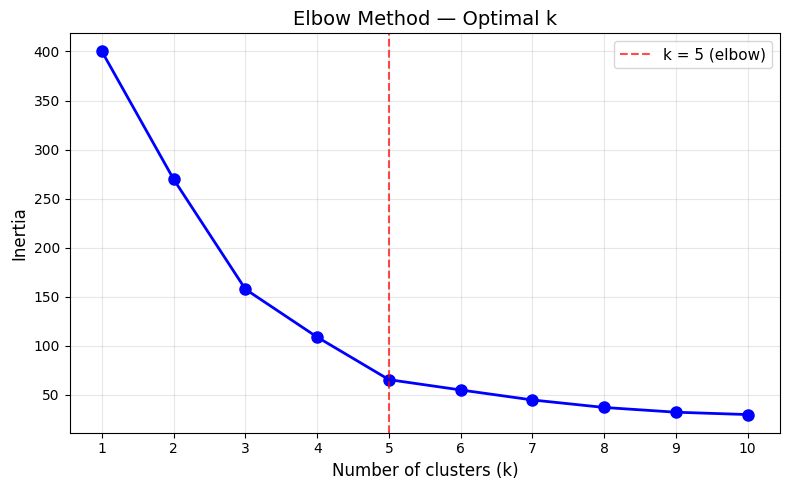

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia_values, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=5, color='r', linestyle='--', alpha=0.7, label='k = 5 (elbow)')
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method — Optimal k', fontsize=14)
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 5. Lõplik mudel

Vali Elbow graafiku põhjal sobiv `optimal_k`, treeni `KMeans`, salvesta `cluster_labels` ja `cluster_centers` ning lisa DataFrame'i veerg `Cluster`. NB! Määra `random_state=42` ja `n_init=10`.



In [5]:
optimal_k = 5

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model.fit(X_scaled)

cluster_labels = kmeans_model.labels_
cluster_centers = kmeans_model.cluster_centers_

df['Cluster'] = cluster_labels

print(f"Optimal k: {optimal_k}")
print(f"Cluster sizes:\n{df['Cluster'].value_counts().sort_index()}")
print(f"\nCluster centers (scaled):\n{cluster_centers}")

Optimal k: 5
Cluster sizes:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster centers (scaled):
[[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


## 6. Klientide klastrid

Koosta hajuvusdiagramm `Annual Income (k$)` ja `Spending Score (1-100)` põhjal, värvi punktid klastrite kaupa ning lisa selged teljemärgised ja pealkiri.



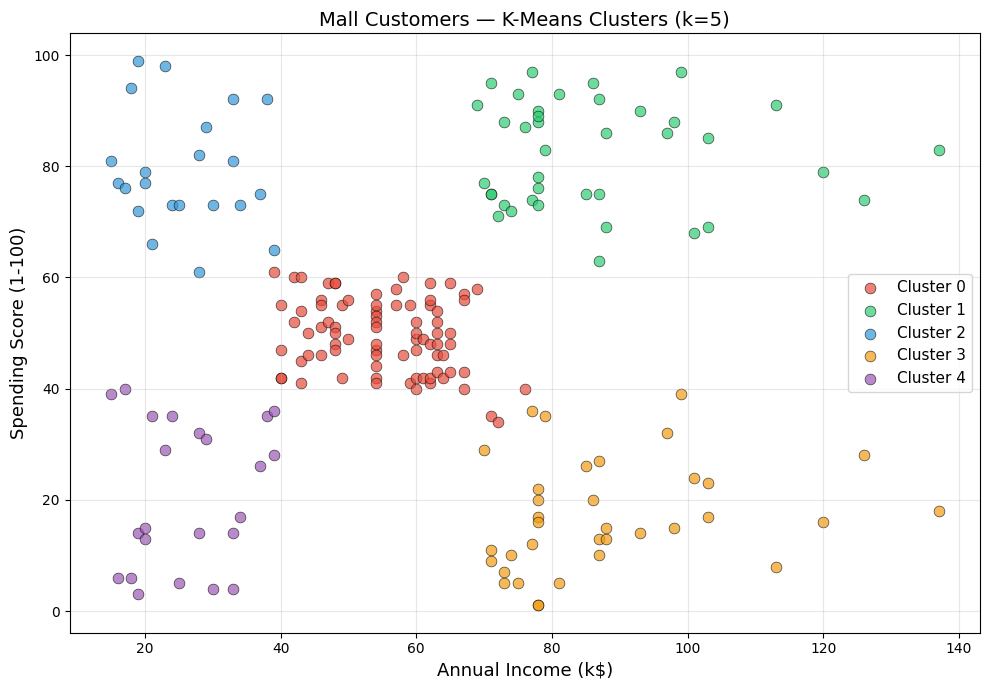

In [6]:
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']
cmap = plt.cm.colors.ListedColormap(colors)

plt.figure(figsize=(10, 7))
for i in range(optimal_k):
    mask = cluster_labels == i
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=colors[i], label=f'Cluster {i}', s=60, alpha=0.7, edgecolors='k', linewidth=0.5
    )

plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.title('Mall Customers — K-Means Clusters (k=5)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Keskpunktid algses mõõtkavas

Teisenda `cluster_centers` skaleeritud ruumist tagasi algmõõtkavasse meetodiga `scaler.inverse_transform` ja salvesta tulemus muutujasse `cluster_centers_original_scale`. Joonista hajuvusdiagramm veergude `Annual Income (k$)` ja `Spending Score (1-100)` põhjal ning lisa samale graafikule tsentroidid eristuva märgistusega. Jäta kujunduses ruumi katsetamiseks: vali markerid, värvid ja suurused enda äranägemise järgi, mängi `alpha` ja võrgustikuga, soovi korral lisa legend ja/või annotatsioonid — eesmärk on, et tsentroidid oleksid selgelt nähtavad ja võrreldavad punktipilvega.



Cluster centers (original scale):
 Cluster   Income (k$)   Spending Score
       0          55.3             49.5
       1          86.5             82.1
       2          25.7             79.4
       3          88.2             17.1
       4          26.3             20.9


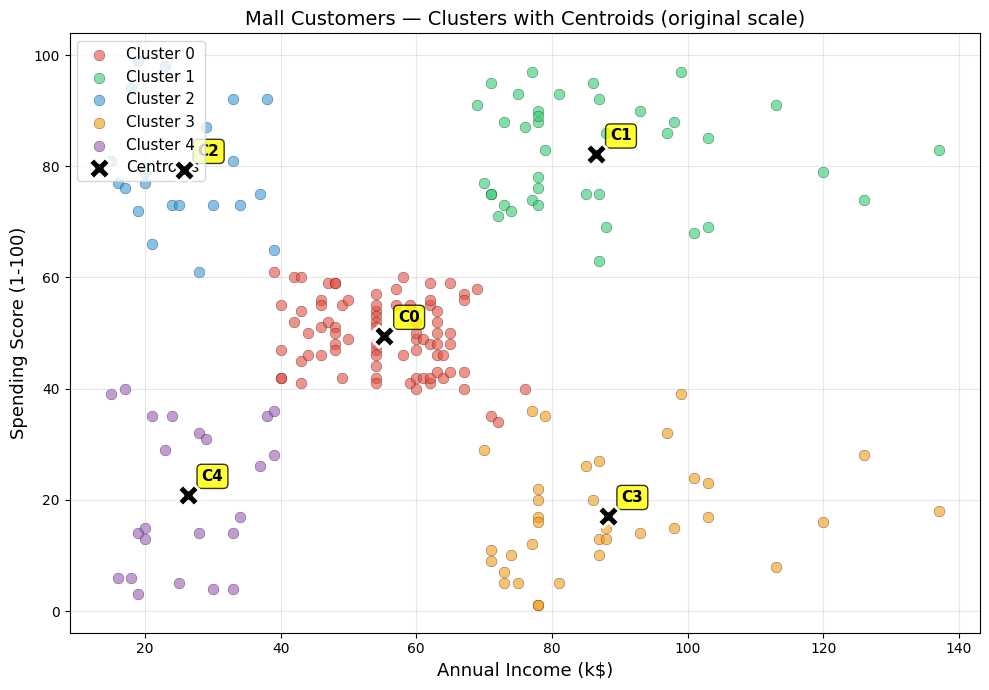

In [7]:
cluster_centers_original_scale = scaler.inverse_transform(cluster_centers)

print("Cluster centers (original scale):")
print(f"{'Cluster':>8}  {'Income (k$)':>12}  {'Spending Score':>15}")
for i, c in enumerate(cluster_centers_original_scale):
    print(f"{i:>8}  {c[0]:>12.1f}  {c[1]:>15.1f}")

colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

plt.figure(figsize=(10, 7))
for i in range(optimal_k):
    mask = cluster_labels == i
    plt.scatter(
        df.loc[mask, 'Annual Income (k$)'],
        df.loc[mask, 'Spending Score (1-100)'],
        c=colors[i], label=f'Cluster {i}', s=60, alpha=0.6, edgecolors='k', linewidth=0.3
    )

plt.scatter(
    cluster_centers_original_scale[:, 0],
    cluster_centers_original_scale[:, 1],
    c='black', marker='X', s=250, linewidths=2, edgecolors='white',
    zorder=10, label='Centroids'
)

for i, c in enumerate(cluster_centers_original_scale):
    plt.annotate(
        f'C{i}', (c[0], c[1]),
        textcoords='offset points', xytext=(10, 10),
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.8)
    )

plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.title('Mall Customers — Clusters with Centroids (original scale)', fontsize=14)
plt.legend(fontsize=11, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
summary = (
    "K-Means clustering with k=5 reveals five distinct customer segments based on annual income and spending score. "
    "Cluster 0 (average income ~55k$, spending ~50) represents the mainstream middle-ground customers with moderate income and moderate spending — "
    "they form the largest group and are best reached through general seasonal campaigns and broad promotions. "
    "Cluster 1 (income ~87k$, spending ~82) consists of high-income, high-spending premium customers who are the most valuable segment "
    "and should be targeted with VIP programs, exclusive brands, and personalized luxury offers. "
    "Cluster 2 (income ~26k$, spending ~79) contains low-income but enthusiastic spenders who could benefit from loyalty reward programs and installment payment options. "
    "Cluster 3 (income ~88k$, spending ~17) represents high-income, low-spending customers — a key opportunity segment "
    "that could be activated through targeted incentives, cashback offers, and personalized recommendations to increase their engagement. "
    "Cluster 4 (income ~26k$, spending ~21) includes low-income, low-spending price-sensitive customers who respond best to basic discounts and budget-friendly deals. "
    "The elbow method clearly indicates k=5 as the optimal number of clusters, as inertia drops sharply up to k=5 and then flattens significantly. "
    "StandardScaler normalization ensured both features contributed equally to distance calculations, preventing income from dominating the clustering."
)

print(summary)

K-Means clustering with k=5 reveals five distinct customer segments based on annual income and spending score. Cluster 0 (average income ~55k$, spending ~50) represents the mainstream middle-ground customers with moderate income and moderate spending — they form the largest group and are best reached through general seasonal campaigns and broad promotions. Cluster 1 (income ~87k$, spending ~82) consists of high-income, high-spending premium customers who are the most valuable segment and should be targeted with VIP programs, exclusive brands, and personalized luxury offers. Cluster 2 (income ~26k$, spending ~79) contains low-income but enthusiastic spenders who could benefit from loyalty reward programs and installment payment options. Cluster 3 (income ~88k$, spending ~17) represents high-income, low-spending customers — a key opportunity segment that could be activated through targeted incentives, cashback offers, and personalized recommendations to increase their engagement. Cluster